In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
from scipy.fft import fft2, fftshift, ifft2, ifftshift
from scipy.interpolate import RectBivariateSpline
from scipy.io import loadmat
from scipy.sparse.linalg import gmres, LinearOperator
from tqdm.auto import tqdm
from types import SimpleNamespace


ROOT = Path.cwd()
print(ROOT)


EX = 3
VER = 5

# comp06_Dbarsolve.m
CUTOFF = 25.0
R_dbar = 4.0  # radius of D-bar solve
n_grid = 64  # grid size for the D-bar solve
RESTART = 50
RTOL = 1e-5
MAXITER = 500

# ex2Kvec_comp.m
R_freq = 7.0  # radius of the scattering-transform k-grid
h_freq = 0.2


args = SimpleNamespace(
    data_dir=ROOT / "data",
    kit4_dir=ROOT / "KIT4_measdata",
    example=EX,
    ver=VER,
    cutoff=CUTOFF,
    R_dbar=R_dbar,
    n_grid=n_grid,
    restart=RESTART,
    rtol=RTOL,
    maxiter=MAXITER,
    R_freq=R_freq,
    h_freq=h_freq,
)

for k, v in vars(args).items():
    print(f"{k}: {v}")

/home/scao/Documents/eit-dbar-pytorch
data_dir: /home/scao/Documents/eit-dbar-pytorch/data
kit4_dir: /home/scao/Documents/eit-dbar-pytorch/KIT4_measdata
example: 3
ver: 5
cutoff: 25.0
R_dbar: 4.0
n_grid: 64
restart: 50
rtol: 1e-05
maxiter: 500
R_freq: 7.0
h_freq: 0.2


In [10]:
def fft_grids(n_grid: int, radius: float) -> tuple[np.ndarray, np.ndarray, float]:
    axis = np.linspace(-radius, radius, n_grid, endpoint=False, dtype=np.float64)
    h = float(axis[1] - axis[0]) if n_grid > 1 else 1.0
    k1, k2 = np.meshgrid(axis, axis, indexing="ij")
    return k1, k2, h


def interp2_bicubic(
    K1: np.ndarray,
    K2: np.ndarray,
    values: np.ndarray,
    xq: np.ndarray,
    yq: np.ndarray,
) -> np.ndarray:
    x = np.asarray(K1[0, :], dtype=np.float64)
    y = np.asarray(K2[:, 0], dtype=np.float64)
    v = np.asarray(values)
    if x[0] > x[-1]:
        x = x[::-1]
        v = v[:, ::-1]
    if y[0] > y[-1]:
        y = y[::-1]
        v = v[::-1, :]
    spl_re = RectBivariateSpline(y, x, np.real(v), kx=3, ky=3)
    spl_im = RectBivariateSpline(y, x, np.imag(v), kx=3, ky=3)
    return spl_re.ev(yq, xq) + 1j * spl_im.ev(yq, xq)


def centered_convolution(
    fundfft: np.ndarray, values: np.ndarray, h: float
) -> np.ndarray:
    return (h**2) * ifftshift(ifft2(fundfft * fft2(fftshift(values))))


class DBarOperator(LinearOperator):
    def __init__(
        self,
        *,
        fundfft: np.ndarray,
        TR: np.ndarray,
        Rind: np.ndarray,
        Nind: int,
        h: float,
    ):
        self.fundfft = fundfft
        self.truncation = TR
        self.Rind = Rind
        self.Nind = Nind
        self.h = h
        super().__init__(dtype=np.float64, shape=(2 * Nind, 2 * Nind))

    def _matvec(self, v: np.ndarray) -> np.ndarray:
        w = np.zeros(self.truncation.shape, dtype=np.complex128)
        w[self.Rind] = v[: self.Nind] + 1j * v[self.Nind :]
        conv = centered_convolution(self.fundfft, self.truncation * np.conj(w), self.h)
        out = w - conv
        return np.concatenate((np.real(out[self.Rind]), np.imag(out[self.Rind])))


#  ex2Kvec_comp.m 

def build_kvec_grid(
    R: float = R_freq, h: float = h_freq
) -> tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    """Port of ex2Kvec_comp.m.

    Returns K1, K2 (2-D meshgrid arrays), Kvec (1-D complex, MATLAB
    column-major ordering), and tMAX.
    """
    N = int(round(R / h))
    K_pos = h / 2.0 + np.arange(N + 1) * h  # [h/2, 3h/2, ..., (2N+1)h/2]
    K_1d = np.concatenate([-K_pos[::-1], K_pos])  # symmetric 1-D axis
    K1, K2 = np.meshgrid(K_1d, K_1d)  # K1[i,j]=K_1d[j], K2[i,j]=K_1d[i]
    grid = K1 + 1j * K2
    mask = np.abs(grid) < R
    Kvec = grid.flatten(order="F")[mask.flatten(order="F")]
    return K1, K2, Kvec, float(R)


#  transfrom_Adj2Trig.m 


def transfrom_Adj2Trig(U_in: np.ndarray, L: int, Ntrig: np.ndarray) -> np.ndarray:
    """Port of transfrom_Adj2Trig.m.

    Parameters
    ----------
    U_in  : (L, L) electrode voltage matrix (scaled, row-reordered)
    L     : number of electrodes (16)
    Ntrig : trig mode indices, length nBasis = L-1

    Returns
    -------
    U_newBase : (L, nBasis) voltages in trig basis
    """
    nBasis = L - 1

    # Adjacent current pattern matrix  (L x L), normalised
    Aad = np.eye(L, dtype=np.float64)
    Aad[np.arange(1, L), np.arange(L - 1)] -= 1.0  # sub-diagonal -1
    Aad[0, L - 1] = -1.0  # wrap-around
    Aad /= np.sqrt(2.0)

    # Trig current pattern matrix  (L x nBasis)
    ll = np.arange(L, dtype=np.float64)
    th = 2.0 * np.pi * ll / L  # electrode-start angles
    normTrig = np.sqrt(2.0 / L)
    Atrig = np.zeros((L, nBasis), dtype=np.float64)
    for k in range(L // 2 - 1):  # MATLAB k = 1 .. L/2-1
        Atrig[:, k] = normTrig * np.cos(Ntrig[k] * th)
    k = L // 2 - 1  # MATLAB k = L/2 (middle cosine)
    Atrig[:, k] = (1.0 / np.sqrt(float(L))) * np.cos(Ntrig[k] * th)
    for k in range(L // 2, nBasis):  # MATLAB k = L/2+1 .. nBasis
        Atrig[:, k] = normTrig * np.sin(Ntrig[k] * th)

    # Change-of-basis coefficients: coeff[j,ii] = Atrig[:,j] · Aad[:,ii]  → (nBasis, L)
    coeff = Atrig.T @ Aad

    # Mean-free correction (port of MATLAB sum check)
    U = U_in.astype(np.float64, copy=True)
    col_sums = U.sum(axis=0)
    adj = np.abs(col_sums) > np.finfo(np.float64).eps
    U[:, adj] -= col_sums[adj]

    # Solve  U_newBase @ coeff = U  in the least-squares sense
    U_newBase, _, _, _ = np.linalg.lstsq(coeff.T, U.T, rcond=None)
    return U_newBase.T  # (L, nBasis)


#  electrodeBuilder.m 


def electrode_builder(L: int) -> np.ndarray:
    """Port of electrodeBuilder.m → (L, 2) array of electrode angle ranges."""
    anglVar = 2.0 * np.pi / (2 * L)
    values = np.arange(2 * L, dtype=np.float64) * anglVar
    # MATLAB: zeros(2,L) filled column-major, then transposed
    mat = values.reshape(2, L, order="F")  # (2, L) column-major fill
    return mat.T  # (L, 2)


# comp02_ND_buildFromKIT4.m

def build_ND_from_kit4(
    U_ad0: np.ndarray,
    U_ad10: np.ndarray,
    *,
    Ntrig: np.ndarray,
    fii: np.ndarray,
    Dfii: float,
    L: int = 16,
) -> tuple[np.ndarray, np.ndarray]:
    """Port of comp02_ND_buildFromKIT4.m.
    Inputs:
    - U_ad0, U_ad10: (L, L) raw electrode voltage measurements for two homogeneous reference conductivities.
    - Ntrig: (nBasis,) trig mode indices (1..L-1)
    - fii: (Nfii,) angles for boundary trace evaluation
    - Dfii: angle spacing for fii
    - L: number of electrodes (KIT has 16)
    
    Returns 
    - NtoD (target): (nBasis, nBasis) matrix mapping Neumann to Dirichlet coefficients in the trig basis.
    - NtoD1 (homogeneous reference): (nBasis, nBasis).
    """
    nBasis = len(Ntrig)
    scale = 2.0 * np.pi / (2 * L)  # electrode length = 2pi/(2L)

    def _prepare(U_raw: np.ndarray) -> np.ndarray:
        # Scale and reorder: MATLAB U_in=[U_in(9:L,:);U_in(1:8,:)]
        U = U_raw * scale
        return np.vstack([U[8:L, :], U[0:8, :]])  # rows 9..16 then 1..8

    U_in0 = _prepare(U_ad0)
    U_in10 = _prepare(U_ad10)

    Uel = transfrom_Adj2Trig(U_in0, L, Ntrig)  # (L, nBasis)
    Uel1 = transfrom_Adj2Trig(U_in10, L, Ntrig)

    # Electrode angle geometry (electrodeBuilder)
    theta_elec = electrode_builder(L)  # (L, 2)
    thetaMid = (theta_elec[:, 0] + theta_elec[:, 1]) / 2  # (L,)
    gammaMid = thetaMid + theta_elec[0, 1]  # shift by pi/L

    # Periodicity: append first row/entry
    gammaMid_ext = np.append(gammaMid, gammaMid[0] + 2.0 * np.pi)  # (L+1,)
    Uel_ext = np.vstack([Uel, Uel[0:1, :]])  # (L+1, nBasis)
    Uel1_ext = np.vstack([Uel1, Uel1[0:1, :]])

    # fii shifted for trace indexing
    fiiBase = fii.copy()
    fii_shift = fii - np.pi
    Nfii = len(fii_shift)

    # Build piecewise-constant boundary traces by walking gammaMid boundaries
    u_trace = np.zeros((Nfii, nBasis))
    u1_trace = np.zeros((Nfii, nBasis))
    for N_idx in range(nBasis):
        nn = 0
        for ii in range(Nfii):
            if fii_shift[ii] <= gammaMid_ext[nn]:
                u_trace[ii, N_idx] = Uel_ext[nn, N_idx]
                u1_trace[ii, N_idx] = Uel1_ext[nn, N_idx]
            else:
                nn += 1
                u_trace[ii, N_idx] = Uel_ext[nn, N_idx]
                u1_trace[ii, N_idx] = Uel1_ext[nn, N_idx]
        u_trace[:, N_idx] -= u_trace[:, N_idx].mean()
        u1_trace[:, N_idx] -= u1_trace[:, N_idx].mean()

    # Cos/sin basis matrix B  (nBasis x Nfii) on fiiBase
    B = np.zeros((nBasis, Nfii))
    for jjj in range(nBasis):
        if jjj < (nBasis + 1) // 2:
            B[jjj] = np.cos(Ntrig[jjj] * fiiBase)
        else:
            B[jjj] = np.sin(Ntrig[jjj] * fiiBase)

    NtoD = Dfii * (B @ u_trace)  # (nBasis, nBasis)
    NtoD1 = Dfii * (B @ u1_trace)
    return NtoD, NtoD1


#  comp03_DN_build.m 


def build_DN_from_ND(
    NtoD: np.ndarray, NtoD1: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """Port of comp03_DN_build.m.

    The MATLAB column/row rearrangement with parVal=ceil(L/2)=8 on a
    15x15 matrix is a no-op, so comp03 reduces to plain matrix inversion.
    """
    return np.linalg.inv(NtoD), np.linalg.inv(NtoD1)


#  comp05_tBIE_psi.m 


def compute_tBIE(
    *,
    Kvec: np.ndarray,
    DN: np.ndarray,
    DN1: np.ndarray,
    Fpsi_BIE: np.ndarray,
    theta: np.ndarray,
    Dtheta: float,
) -> np.ndarray:
    """Port of comp05_tBIE_psi.m (vectorised over all k).

    tBIE(k) = Dtheta * sum_j exp(i*conj(k)*exp(-i*theta_j)) * LLpsi_j
    where  LLpsi = synth_trig( (DN-DN1) @ Fpsi_BIE[:,k_idx] )
    """
    Ntrig_05 = np.array([1, 2, 3, 4, 5, 6, 7, 8, 7, 6, 5, 4, 3, 2, 1], dtype=int)
    nBasis = len(Ntrig_05)
    Ntheta = len(theta)

    # Trig synthesis matrix  T_basis: (Ntheta, nBasis)
    T_basis = np.zeros((Ntheta, nBasis), dtype=np.float64)
    for jjj in range(nBasis):
        if jjj < (nBasis + 1) // 2:
            T_basis[:, jjj] = (1.0 / np.sqrt(np.pi)) * np.cos(Ntrig_05[jjj] * theta)
        else:
            T_basis[:, jjj] = (1.0 / np.sqrt(np.pi)) * np.sin(Ntrig_05[jjj] * theta)

    FLLpsi = (DN - DN1) @ Fpsi_BIE  # (nBasis, num_k)
    LLpsi = T_basis @ FLLpsi  # (Ntheta, num_k)

    # exp( i * conj(k) * exp(-i*theta) )  ->  (Ntheta, num_k)
    exp_phase = np.exp(
        1j * np.conj(Kvec)[np.newaxis, :] * np.exp(-1j * theta[:, np.newaxis])
    )
    tBIE = Dtheta * np.einsum("ij,ij->j", exp_phase, LLpsi)  # (num_k,)
    return tBIE


def build_dbar_inputs_from_kit4_data(
    data_dir: Path,
    kit4_dir: Path,
    *,
    ex: int,
    ver: int,
    cutoff: float,
    R_dbar: float,
    n_grid: int,
    R_freq: float,
    h_freq: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, float, np.ndarray, int]:
    """Full Python pipeline for comp01 stages 1-5.

    Loads raw KIT4 measurement for experiment `ex`, version `ver` and runs:
    ex2Kvec_comp -> comp02 -> comp03 -> comp05 -> scattering grid assembly.
    """

    mesh_dat = loadmat(data_dir / "mesh.mat")
    elec_dat = loadmat(data_dir / "elecMeas_adj.mat")
    ang_dat = loadmat(data_dir / "angPars_adj.mat")
    theta_dat = loadmat(data_dir / "theta.mat")
    psi_dat = loadmat(data_dir / "psi_BIE.mat")
    meas_dat = loadmat(kit4_dir / f"dataMat_adj_{ex}_{ver}.mat")

    p = np.asarray(mesh_dat["p"], dtype=np.float64) # (2, num_nodes) array of node coordinates (x; y)
    zvec = p[0, :].astype(np.complex128) + 1j * p[1, :].astype(np.complex128) # z_vector in the D-bar paper, (num_nodes,) complex array of node locations

    Ntrig = elec_dat["Ntrig"].ravel().astype(int)
    fii = ang_dat["fii"].ravel().astype(np.float64)
    Dfii = float(ang_dat["Dfii"].ravel()[0])
    theta = theta_dat["theta"].ravel().astype(np.float64)
    Dtheta = float(theta_dat["Dtheta"].ravel()[0])
    Fpsi_BIE = np.asarray(psi_dat["Fpsi_BIE"], dtype=np.complex128)  # (15, num_k)
    U_ad0 = np.asarray(meas_dat["U_ad0"], dtype=np.float64)
    U_ad10 = np.asarray(meas_dat["U_ad10"], dtype=np.float64)

    # ex2Kvec_comp.m
    K1, K2, Kvec, tMAX = build_kvec_grid(R=R_freq, h=h_freq)

    # comp02_ND_buildFromKIT4.m
    NtoD, NtoD1 = build_ND_from_kit4(U_ad0, U_ad10, Ntrig=Ntrig, fii=fii, Dfii=Dfii)

    # comp03_DN_build.m
    DN, DN1 = build_DN_from_ND(NtoD, NtoD1)

    # comp05_tBIE_psi.m
    tBIE = compute_tBIE(
        Kvec=Kvec,
        DN=DN,
        DN1=DN1,
        Fpsi_BIE=Fpsi_BIE,
        theta=theta,
        Dtheta=Dtheta,
    )

    # Scattering grid assembly
    inside_tmax = np.abs(K1 + 1j * K2) < tMAX
    if tBIE.size != int(inside_tmax.sum()):
        raise ValueError(
            f"tBIE length {tBIE.size} does not match |K|<tMAX count {int(inside_tmax.sum())}."
        )
    scatBIE_34 = np.zeros_like(K1, dtype=np.complex128)
    scatBIE_34_flat = scatBIE_34.reshape(-1, order="F")
    scatBIE_34_flat[inside_tmax.reshape(-1, order="F")] = tBIE
    scatBIE_34 = scatBIE_34_flat.reshape(K1.shape, order="F")
    scatBIE_34[np.abs(np.real(scatBIE_34)) > cutoff] = 0
    scatBIE_34[np.abs(np.imag(scatBIE_34)) > cutoff] = 0

    # Computational D-bar k-grid
    k1, k2, h = fft_grids(n_grid=n_grid, radius=2.3 * R_dbar)
    k = k1 + 1j * k2
    Rind = np.abs(k) < R_dbar
    Nind = int(Rind.sum())

    scatvec = interp2_bicubic(K1, K2, scatBIE_34, k1[Rind], k2[Rind])
    scat = np.zeros_like(k, dtype=np.complex128)
    scat[Rind] = scatvec

    return p, zvec, k1, k2, h, scat, Nind


# ── comp06_Dbarsolve.m ────────────────────────────────────────────────────────


def Dbar_solve(
    *,
    zvec: np.ndarray,
    k1: np.ndarray,
    k2: np.ndarray,
    h: float,
    scat: np.ndarray,
    Nind: int,
    R: float,
    restart: int,
    rtol: float,
    maxiter: int,
) -> np.ndarray:
    """
    GMRES solve of the D-bar integral equation (port of comp06_Dbarsolve.m).

    Inputs:
    - zvec: (num_nodes,) complex node locations
    - k1, k2: (n_grid, n_grid) real and imaginary parts
        of the computational k-grid (not just the inside-R part)
    - h: grid spacing for the k-grid
    - scat: (n_grid, n_grid) complex scattering transform on the k-grid
    - Nind: number of k-grid points inside radius R
    - R: radius of the D-bar solve (defines the inside-R region of the k-grid)

    Output:
    - recon: (num_nodes,) real reconstructed conductivity values at zvec nodes
    """
    k = k1 + 1j * k2

    ktmp = k.copy()
    ind0 = np.abs(k) < 1e-14
    if not np.any(ind0):
        raise ValueError("Origin not found on computational k-grid.")
    ktmp[ind0] = 1.0

    scatk = scat / np.conj(ktmp) # scattering transform divided by conj(k)
    scatk[ind0] = 0.0

    fund = 1.0 / (np.pi * ktmp)
    fund[ind0] = 0.0

    s = abs(np.min(k1))
    ep = s / 10.0
    RR = (s - ep) / 2.0
    fund[np.abs(k) >= s] = 0.0
    medind = (np.abs(k) < s) & (np.abs(k) > 2.0 * RR)
    fund[medind] *= 1.0 - (np.abs(k[medind]) - 2.0 * RR) / ep

    fundfft = np.asarray(fft2(fftshift(fund)))

    Rind = np.abs(k) < R
    rhs = np.concatenate(
        (np.ones(Nind, dtype=np.float64), np.zeros(Nind, dtype=np.float64))
    )
    init_guess = rhs.copy()

    recon = np.ones(zvec.shape[0], dtype=np.complex128)


    # For each node z (points of reconstruction), solve a separate D-bar equation in k with a z-dependent right-hand side 
    # then compute mu(z,0) and store recon(z)=mu(z,0)^2.
    # MATLAB original code uses a for-loop (line 91--99 comp06_Dbarsolve.m)
    for iii, z in enumerate(tqdm(zvec, total=zvec.size, desc="D-bar solve"), start=1):
        TR = (1.0 / (4.0 * np.pi)) * scatk * np.exp(-1j * (k * z + np.conj(k * z)))
        A = DBarOperator(fundfft=fundfft, TR=TR, Rind=Rind, Nind=Nind, h=h)

        w, info = gmres(
            A, rhs, x0=init_guess, restart=restart, rtol=rtol, atol=0.0, maxiter=maxiter
        )
        if info != 0:
            raise RuntimeError(
                f"GMRES failed at node {iii}/{zvec.size} with info={info}."
            )
        init_guess = w.copy()  # warm start for next solve (changed from MATLAB)
        mu = np.zeros_like(k, dtype=np.complex128)
        mu[Rind] = w[:Nind] + 1j * w[Nind:]
        recon[iii - 1] = mu[ind0][0] ** 2

    return np.real(recon)


def plot_reconstruction(p: np.ndarray, recon: np.ndarray, data_dir: Path):
    mesh = loadmat(data_dir / "mesh.mat")
    ref_mat = loadmat(data_dir / "reconstruction.mat")
    t = np.asarray(mesh["t"])
    triangles = np.asarray(t[:3, :].T - 1, dtype=np.int32)
    ref_recon = np.asarray(ref_mat["recon"], dtype=np.float64).ravel()
    py_recon = recon.ravel()

    vmin = float(min(py_recon.min(), ref_recon.min()))
    vmax = float(max(py_recon.max(), ref_recon.max()))

    fig, (ax_py, ax_ref, ax_cbar) = plt.subplots(
        1,
        3,
        num=2,
        clear=True,
        figsize=(10, 4),
        gridspec_kw={"width_ratios": [1.0, 1.0, 0.05]},
    )
    triang = mtri.Triangulation(p[0, :], p[1, :], triangles)

    py_plot = ax_py.tripcolor(triang, py_recon, cmap="jet", vmin=vmin, vmax=vmax)
    ax_py.set_title("Python")
    ax_py.set_aspect("equal")
    ax_py.axis("off")

    ax_ref.tripcolor(triang, ref_recon, cmap="jet", vmin=vmin, vmax=vmax)
    ax_ref.set_title("MATLAB reference")
    ax_ref.set_aspect("equal")
    ax_ref.axis("off")

    fig.colorbar(py_plot, cax=ax_cbar)
    fig.tight_layout()
    return fig, (ax_py, ax_ref)



D-bar solve:   0%|          | 0/8321 [00:00<?, ?it/s]

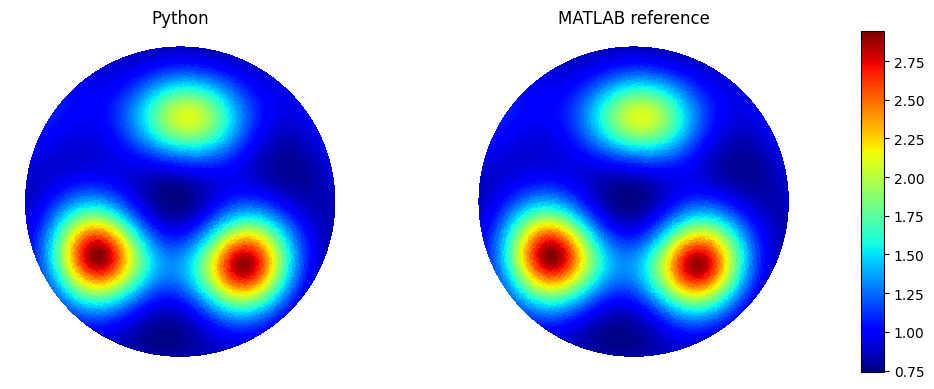

In [11]:

p, zvec, k1, k2, h, scat, Nind = build_dbar_inputs_from_kit4_data(
        args.data_dir,
        args.kit4_dir,
        ex=args.example,
        ver=args.ver,
        cutoff=args.cutoff,
        R_dbar=args.R_dbar,
        n_grid=args.n_grid,
        R_freq=args.R_freq,
        h_freq=args.h_freq,
    )
recon = Dbar_solve(
        zvec=zvec,
        k1=k1,
        k2=k2,
        h=h,
        scat=scat,
        Nind=Nind,
        R=args.R_dbar,
        restart=args.restart,
        rtol=args.rtol,
        maxiter=args.maxiter,
    )
fig, ax = plot_reconstruction(p, recon, args.data_dir)
plt.show()